# Imports

In [411]:
import sklearn
from sklearn.model_selection import train_test_split

In [412]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# get dataset

Load the real world dataset and display the structure

In [413]:
dataset = sklearn.datasets.load_diabetes( return_X_y=False, as_frame=False)

''' dataset = sklearn.datasets.fetch_california_housing( return_X_y=False, as_frame=False) '''

' dataset = sklearn.datasets.fetch_california_housing( return_X_y=False, as_frame=False) '

In [414]:
print(dataset.data[0])

[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
 -0.04340085 -0.00259226  0.01990749 -0.01764613]


In [415]:
print(dataset.target)

[151.  75. 141. 206. 135.  97. 138.  63. 110. 310. 101.  69. 179. 185.
 118. 171. 166. 144.  97. 168.  68.  49.  68. 245. 184. 202. 137.  85.
 131. 283. 129.  59. 341.  87.  65. 102. 265. 276. 252.  90. 100.  55.
  61.  92. 259.  53. 190. 142.  75. 142. 155. 225.  59. 104. 182. 128.
  52.  37. 170. 170.  61. 144.  52. 128.  71. 163. 150.  97. 160. 178.
  48. 270. 202. 111.  85.  42. 170. 200. 252. 113. 143.  51.  52. 210.
  65. 141.  55. 134.  42. 111.  98. 164.  48.  96.  90. 162. 150. 279.
  92.  83. 128. 102. 302. 198.  95.  53. 134. 144. 232.  81. 104.  59.
 246. 297. 258. 229. 275. 281. 179. 200. 200. 173. 180.  84. 121. 161.
  99. 109. 115. 268. 274. 158. 107.  83. 103. 272.  85. 280. 336. 281.
 118. 317. 235.  60. 174. 259. 178. 128.  96. 126. 288.  88. 292.  71.
 197. 186.  25.  84.  96. 195.  53. 217. 172. 131. 214.  59.  70. 220.
 268. 152.  47.  74. 295. 101. 151. 127. 237. 225.  81. 151. 107.  64.
 138. 185. 265. 101. 137. 143. 141.  79. 292. 178.  91. 116.  86. 122.
  72. 

# Data augmentation

Create a random permuntation so I can make sure that the model works and not only with single permuntation

In [416]:
X = dataset.data
Y = dataset.target

In [417]:
#set seed for this to be reproducible
np.random.seed(42)

n = X.shape[0]
perm = np.random.permutation(n)

X = X[perm]
Y = Y[perm]

In [418]:
print(X[0])

[ 0.04534098 -0.04464164 -0.00620595 -0.01599898  0.1250187   0.1251981
  0.019187    0.03430886  0.03243232 -0.0052198 ]


Create the training, test split

In [419]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


In [420]:
X_train.shape, y_train.shape


((353, 10), (353,))

In [421]:
X_test.shape, y_test.shape

((89, 10), (89,))

The trouble I ran into was the dataset not being expressive enough, so I'm creating polynomial features

In [422]:
# Adding x^^2
''' X_train = np.c_[X_train, X_train**2]
X_test = np.c_[X_test, X_test**2] '''

# Adding some x^^2 and x1x2 features
''' X_train = np.c_[X_train, X_train[:, 0]**2, X_train[:, 1]**2, X_train[:, 0]*X_train[:, 1]]
X_test = np.c_[X_test, X_test[:, 0]**2, X_test[:, 1]**2, X_test[:, 0]*X_test[:, 1]] '''

' X_train = np.c_[X_train, X_train[:, 0]**2, X_train[:, 1]**2, X_train[:, 0]*X_train[:, 1]]\nX_test = np.c_[X_test, X_test[:, 0]**2, X_test[:, 1]**2, X_test[:, 0]*X_test[:, 1]] '

In [423]:
print(X_train.shape)
print(X_test.shape)

(353, 10)
(89, 10)


Add a bias (intercept) to the datapoints so the weights are not being updated that harshly

In [424]:
def add_bias(X):
    return np.c_[np.ones(X.shape[0]), X]

X_train = add_bias(X_train)
X_test = add_bias(X_test)

# helper functions

Determine simple functions

In [425]:
#Error

def calculcateError( label, predi):
  predictionError = ( predi - label ) ** 2
  ''' print( predictionError) '''
  return predictionError


def sumError(y_pred, labels):
  totalModelError = 0
  for i in range(len(y_pred)):

    error  = calculcateError( labels[i], y_pred[i])
    totalModelError += error

  return totalModelError


# Non squared error
def simpleError( label, predi):
  predictionError =  predi - label
  ''' print( predictionError) '''
  return predictionError




# Non squared error
def simpleSumError(y_pred, labels):
  totalModelError = 0
  for i in range(len(y_pred)):

    error  = simpleError( labels[i], y_pred[i])
    totalModelError += error

  return totalModelError

#Mean squared error
def mse(y_pred, y):
    return np.mean((y_pred - y) ** 2)


# crude and easy implementation of a prediction
def predict(X, w):
    return X @ w


In [426]:

def getFeatureBlame( X, y, y_pred):

    # figure out how each feature contributed to those errors
    return (X.T @ (y_pred - y))

Ridge specific helpers

In [427]:
# ridge addon for weights
def getRidgePenalty(alpha, w):
    total = 0
    for i in range(len(w)):
      total += (w[i] ** 2)


    return alpha * total


def getRidgeGradient(alpha, w):

  reg = 2 * alpha * w
  reg[0] = 0
  return reg

# Ridge model

In [428]:
# L2, ridge
def ridge(X, y, alpha = 1, lR = 0.001, epochs = 100000):


  prev_loss = float("inf")


  m, n = X.shape

  # Create weights
  w = np.zeros(n)

  for i in range(epochs):
    y_pred = predict(X, w)


    loss  = sumError(y_pred, y)

    # Drop learning rate if we see no  development
    if loss >= prev_loss:
      lR *= 0.8
    prev_loss = loss

    gradient = (2 / m) *  getFeatureBlame(X, y ,y_pred) + getRidgeGradient(alpha, w)
    '''   print(gradient) '''
    # update weights
    w = w - lR * gradient


    ''' print(w ) '''
  return w

# Lets find good weights


Fiddleling around with alpha and learning rate to find a good candidate or in a way "fitting" the model. Takes aprox 2min

In [429]:
best_mse = float("inf")
best_alpha = None
best_lr = None
best_w = None

for alpha in [ 1e-8, 1e-7, 1e-6  ]:
  for lr in [  1e-4 , 1e-3, 1e-2]:

    w = ridge(X_train, y_train, alpha=alpha, lR=lr, epochs = 100000)
    pred = predict(X_test, w)
    current_mse = mse(pred, y_test)
    print("alpha: ", alpha,"lr: ", lr,"mse: ", current_mse)


    if current_mse < best_mse:
      best_mse = current_mse
      best_alpha = alpha
      best_lr = lr
      best_w = w


print("\nBEST RESULT:")
print("alpha:", best_alpha, "lr:", best_lr, "mse:", best_mse)

alpha:  1e-08 lr:  0.0001 mse:  3880.113256769164
alpha:  1e-08 lr:  0.001 mse:  2630.034696889968
alpha:  1e-08 lr:  0.01 mse:  2579.3385497105064
alpha:  1e-07 lr:  0.0001 mse:  3880.11369842307
alpha:  1e-07 lr:  0.001 mse:  2630.0375751419074
alpha:  1e-07 lr:  0.01 mse:  2579.321907158391
alpha:  1e-06 lr:  0.0001 mse:  3880.1181149375834
alpha:  1e-06 lr:  0.001 mse:  2630.0663627571275
alpha:  1e-06 lr:  0.01 mse:  2579.1556574571355

BEST RESULT:
alpha: 1e-06 lr: 0.01 mse: 2579.1556574571355


In [430]:


testPredictions = predict(X_test, best_w)
print(sumError(testPredictions, y_test))

mse = mse(X_test, best_w)
rmse = np.sqrt(mse)
print(mse, rmse)

229544.853513685
71560.01957293937 267.5070458379356


In [431]:
for i in range(10):
  print("Error for " + str(i)
        + ": " + str(calculcateError(testPredictions[i], y_test[i]))
        + ", Prediction: " + str(testPredictions[i])
        + ", label : " +str( y_test[i]))

Error for 0: 706.190903389852, Prediction: 167.57425264028797, label : 141.0
Error for 1: 5100.950385637493, Prediction: 180.42093800586417, label : 109.0
Error for 2: 2412.996003968452, Prediction: 231.87774431107167, label : 281.0
Error for 3: 16.031414348184253, Prediction: 267.0039248679495, label : 263.0
Error for 4: 8107.1666678151805, Prediction: 151.0398060183116, label : 61.0
Error for 5: 180.16672155064276, Prediction: 186.57738022774083, label : 200.0
Error for 6: 10502.36430195785, Prediction: 189.51895637749462, label : 292.0
Error for 7: 5012.189957150389, Prediction: 143.79682165994734, label : 73.0
Error for 8: 24.76157056983402, Prediction: 78.02390006432407, label : 83.0
Error for 9: 768.8346857210619, Prediction: 143.7278683948309, label : 116.0


In [432]:
print(best_w)

[ 153.0428706   -42.40778613 -173.74086585  559.82298378  302.67336602
  -72.16446457 -114.91113826 -242.38948511   93.2180607   486.07260764
   70.05774988]


 # Visualization

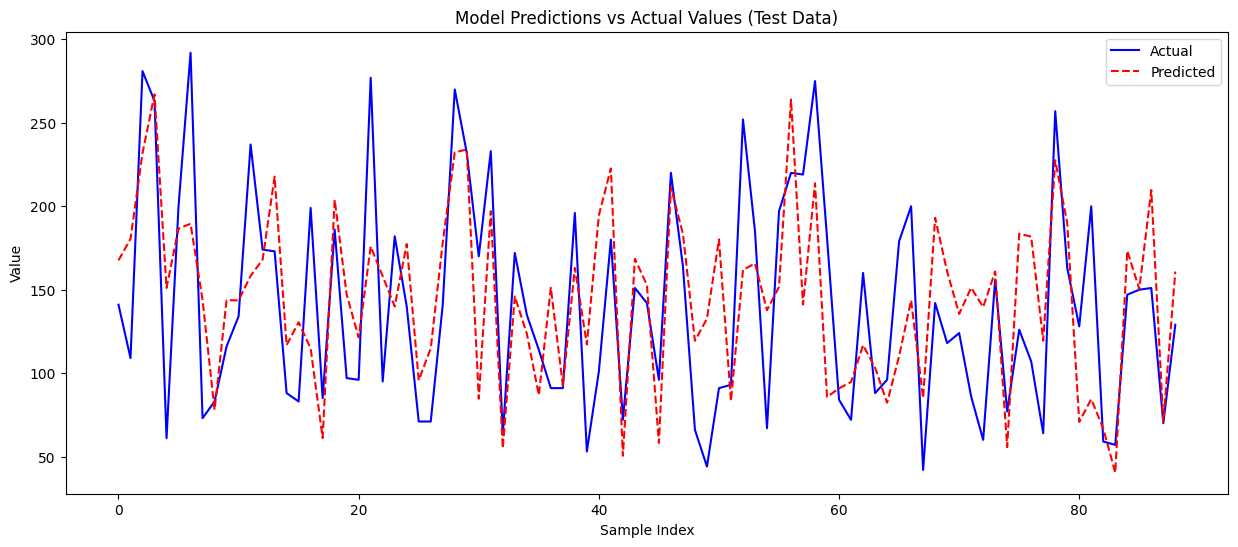

In [433]:
num_samples_to_plot = len(X_test)
indices = np.arange(num_samples_to_plot)

plt.figure(figsize=(15, 6))
plt.plot(indices, y_test[:num_samples_to_plot], 'b-', label='Actual')
plt.plot(indices, testPredictions[:num_samples_to_plot], 'r--', label='Predicted')
plt.title('Model Predictions vs Actual Values (Test Data)')
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.legend()
plt.show()

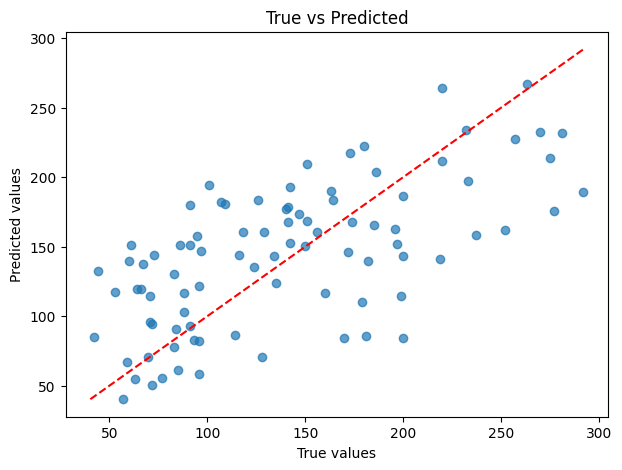

In [434]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, testPredictions, alpha=0.7)
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("True vs Predicted")

min_val = min(y_test.min(), testPredictions.min())
max_val = max(y_test.max(), testPredictions.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.show()